In [1]:
import pandas as pd

df = pd.read_csv('/content/online_retail.csv')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(58891, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58891 entries, 0 to 58890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    58891 non-null  object 
 1   StockCode    58891 non-null  object 
 2   Description  58730 non-null  object 
 3   Quantity     58891 non-null  int64  
 4   InvoiceDate  58891 non-null  object 
 5   UnitPrice    58890 non-null  float64
 6   CustomerID   36982 non-null  float64
 7   Country      58890 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.6+ MB


In [4]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,161
Quantity,0
InvoiceDate,0
UnitPrice,1
CustomerID,21909
Country,1


In [5]:
df=df.dropna(subset=['CustomerID'])
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [6]:
df.duplicated().sum()

np.int64(583)

In [2]:
import pandas as pd
df = pd.read_csv('/content/online_retail.csv')
df=df.dropna(subset=['CustomerID'])


df=df.drop_duplicates()
df.shape

(209016, 8)

In [3]:
print(df.shape)
print(df.columns)

(209016, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [4]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

customer_stats = df.groupby('CustomerID').agg(
    AveragePurchaseValue=('TotalAmount', 'mean'),
    PurchaseFrequency=('InvoiceNo', 'nunique'),
    CustomerLifetimeValue=('TotalAmount', 'sum')
).reset_index()

customer_stats.head()

,CustomerID,AveragePurchaseValue,PurchaseFrequency,CustomerLifetimeValue
0,12346.0,0.000000,2,0.00
1,12347.0,22.506935,5,2790.86
2,12348.0,53.115714,3,1487.24
3,12350.0,19.670588,1,334.40
4,12352.0,12.524583,8,601.18


In [5]:
features = customer_stats[
    ['AveragePurchaseValue', 'PurchaseFrequency', 'CustomerLifetimeValue']
]

features.head()

,AveragePurchaseValue,PurchaseFrequency,CustomerLifetimeValue
0,0.000000,2,0.00
1,22.506935,5,2790.86
2,53.115714,3,1487.24
3,19.670588,1,334.40
4,12.524583,8,601.18


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-0.22976128, -0.29933864, -0.27812694],
       [-0.04579103,  0.17198524,  0.28751612],
       [ 0.20440316, -0.14223068,  0.02330236],
       [-0.06897515, -0.45644661, -0.21035176],
       [-0.12738614,  0.64330913, -0.1562816 ]])

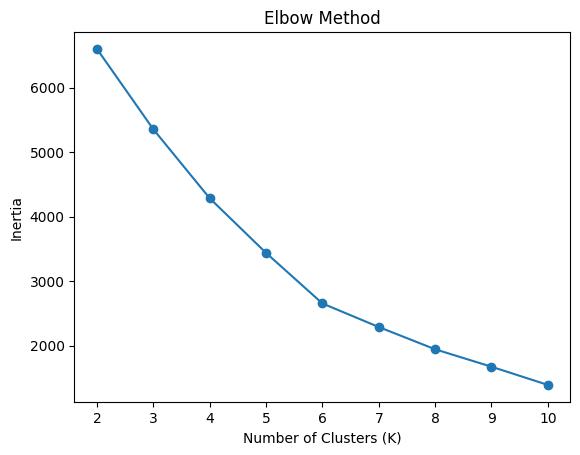

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

customer_stats['Cluster'] = kmeans.fit_predict(scaled_features)

customer_stats.head()

,CustomerID,AveragePurchaseValue,PurchaseFrequency,CustomerLifetimeValue,Cluster
0,12346.0,0.000000,2,0.00,0
1,12347.0,22.506935,5,2790.86,0
2,12348.0,53.115714,3,1487.24,0
3,12350.0,19.670588,1,334.40,0
4,12352.0,12.524583,8,601.18,0


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

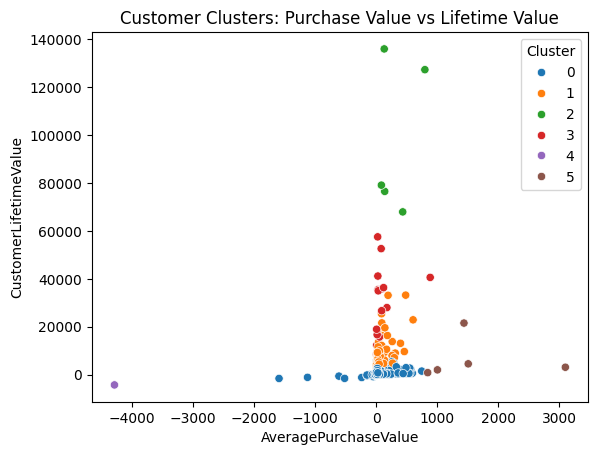

In [12]:
sns.scatterplot(
    data=customer_stats,
    x='AveragePurchaseValue',
    y='CustomerLifetimeValue',
    hue='Cluster',
    palette='tab10'
)
plt.title('Customer Clusters: Purchase Value vs Lifetime Value')
plt.show()

In [13]:
cluster_profile = customer_stats.groupby('Cluster')[
    ['AveragePurchaseValue', 'PurchaseFrequency', 'CustomerLifetimeValue']
].mean()

cluster_profile

,AveragePurchaseValue,PurchaseFrequency,CustomerLifetimeValue
Cluster,,,
0,24.586744,2.527901,696.103359
1,42.407790,13.794521,4802.866027
2,315.884887,26.400000,97375.868000
3,97.591632,61.500000,27697.266667
4,-4287.630000,1.000000,-4287.630000
5,1576.005333,1.800000,6398.520000


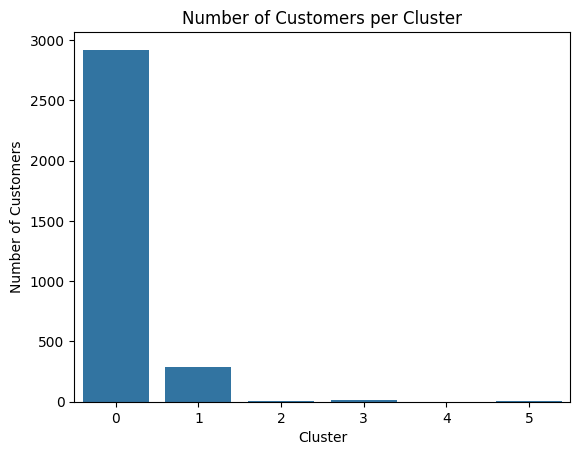

In [14]:
sns.countplot(data=customer_stats, x='Cluster')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

Insights


Cluster 0: Large customer group with lower purchase value — use regular offers and engagement campaigns.


Cluster 1: Higher-value customers — provide personalized offers and loyalty rewards.


Clusters 2–5: Smaller customer groups — use targeted promotions based on their purchasing behaviour.**bold text**